In [5]:
#1 KM DATA
###########################################################################################

#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
netCDF=netCDF.isel(time=np.arange(0,140+1))
# parcel=parcel.isel(time=np.arange(0,140+1))

res='1km'

In [9]:
# #250 M DATA
# ###########################################################################################

# #Loading in Packages and Data

# #Importing Packages
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.colors as colors
# import matplotlib.ticker as ticker
# import matplotlib.cm as cm
# from matplotlib.colors import Normalize
# from matplotlib.ticker import MaxNLocator
# from matplotlib.ticker import ScalarFormatter
# import matplotlib.gridspec as gridspec
# import xarray as xr
# import os; import time
# import pickle
# import h5py
# ###############################################################
# def coefs(coefficients,degree):
#     coef=coefficients
#     coefs=""
#     for n in range(degree, -1, -1):
#         string=f"({coefficients[len(coef)-(n+1)]:.1e})"
#         coefs+=string + f"x^{n}"
#         if n != 0:
#             coefs+=" + "
#     return coefs
# ###############################################################

# #Importing Model Data
# check=False
# dir='/home/air673/koa_scratch/'

# netCDF=xr.open_dataset(dir+'cm1out.nc') #***
# res='250m'

In [10]:
#LOAD VARIABLES
################################################################################
def load_vars(data):
    
    ###########################
    # Equivalent Potential Temperature (theta_v)
    # surface_prs=data['prs'].mean(dim=("time",'yh','xh')); surface_prs=surface_prs[0]
    
    
    print('PRESSURE VARIABLES'); ################################# PRESSURE VARIABLES
    p0=1e5
    P=data['prs'].data
    
    # print('THERMODYNAMICS'); ################################# THERMODYNAMICS
    Rd=287.04
    # Rv=461.5
    Cpd=1005.7 #+-2.5
    # Cpv=1870 #+-25
    # Cpl=4190 #+-30
    # Lv0=2.501e6
    # def Lv(T): #Kirchoff's formula L_i,ii= L_i,ii0+(Cpii-Cpi)*(T-273.15)
    #     Llv=Lv0+(Cpv-Cpl)*(T-273.15) #should it be Cpl. is Cl the same?***
    #     return Llv
    
    # print('TEMPERATURE'); ################################# TEMPERATURE
    theta=data['th'].data
    T=theta*(P/p0)**(Rd/Cpd)
    
    # print('VIRTUAL TEMPERATURE'); ################################# VIRTUAL TEMPERATURE
    eps=0.622
    rv=data['qv'].data
    scalar=(1+rv/eps)/(1+rv)
    Tv=T*scalar

    return Rd,Cpd,p0,P,Tv

In [11]:
def make_theta_v(Rd,Cpd,p0,P,Tv):
    theta_v=Tv*(p0/P)**(Rd/Cpd)
    return theta_v

In [12]:
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
def initiate_array():
    # Define array dimensions (adjust based on your netCDF)
    t_size = len(netCDF['time'])  # Number of timesteps
    z_size = len(netCDF['zh'])    # Number of vertical levels
    y_size = len(netCDF['yh'])    # Number of y-axis points
    x_size = len(netCDF['xh'])    # Number of x-axis points
    
    with h5py.File(dir2 + 'Variable_Calculation/' + 'theta_v'+f'_{res}'+'.h5', 'a') as f:
        # Check if the dataset 'theta_v' already exists
        if 'theta_v' not in f:
            # Create a dataset with the full size for all time steps (initially empty)
            f.create_dataset('theta_v', 
                             (t_size, z_size, y_size, x_size),  # Full size for all timesteps
                             maxshape=(None, z_size, y_size, x_size),  # Unlimited timesteps (can grow along time dimension)
                             dtype='float64', 
                             chunks=(1, z_size, y_size, x_size))  # Chunks for time axis to allow resizing

            
def add_timestep_at_index(timestep_data, index):
    with h5py.File(dir2 + 'Variable_Calculation/' + 'theta_v'+f'_{res}'+'.h5', 'a') as f:
        # Access the existing dataset 'theta_v'
        dataset = f['theta_v']
        
        # Assign the new timestep data at the specified index
        dataset[index] = timestep_data

In [ ]:
#RUNNING

In [13]:
#MAKING ARRAY TO STORE theta_v
initiate_array()

#CALCULATING AND APPENDING TO DATA EACH TIMESTEP
for t in range(len(netCDF['time'])):
    if np.mod(t,1)==0: print(f'Current time {t}')
    data=netCDF.isel(time=t)
    [Rd,Cpd,p0,P,Tv] = load_vars(data)
    theta_v=make_theta_v(Rd,Cpd,p0,P,Tv)
    add_timestep_at_index(theta_v, t)

Current time 0
PRESSURE VARIABLES
Current time 1
PRESSURE VARIABLES


In [7]:
# #READING FINAL OUTPUT
# with h5py.File(dir2 + 'Variable_Calculation/' + 'theta_v_1km.h5', 'a') as f:
#     # Access the existing dataset 'MSE'
#     dataset = f['theta_v'][:]

Text(0.5, 1.0, 'theta_v at t = 50, z = 30 m')

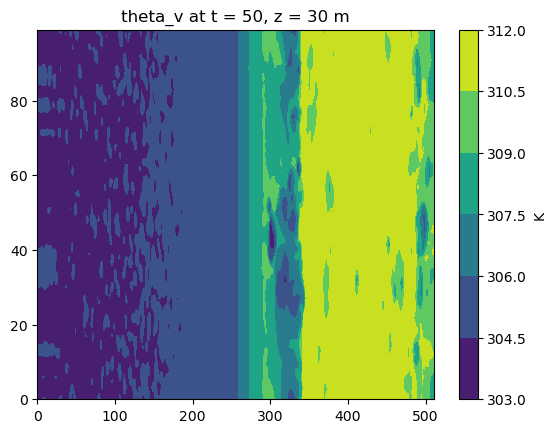

In [8]:
# plt.contourf(dataset[50,0])
# plt.colorbar(label='K')
# plt.title("theta_v at t = 50, z = 30 m")